<a href="https://colab.research.google.com/github/nithiyasri-s21/FAKE-CURRENCY-DETECTION/blob/main/currency5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1 — INSTALL
!apt-get install -y -q tesseract-ocr
!pip install -q pytesseract scikit-image
print('✅ Done')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
✅ Done


In [ ]:
# CELL 2 — UPLOAD DATASET
from google.colab import files
import zipfile, os

IMG_EXTS = {'.jpg','.jpeg','.png','.bmp'}
print('📂 Upload FAKE 500.zip and REAL 500.zip')
uploaded = files.upload()

os.makedirs('/content/FAKE', exist_ok=True)
os.makedirs('/content/REAL', exist_ok=True)
for fname, data in uploaded.items():
    p = f'/content/{fname}'
    open(p,'wb').write(data)
    dest = '/content/FAKE' if 'fake' in fname.lower() else '/content/REAL'
    with zipfile.ZipFile(p,'r') as z: z.extractall(dest)
    print(f'  ✅ {fname} → {dest}')

def find_dir(base):
    for root,_,fs in os.walk(base):
        if any(os.path.splitext(f)[1].lower() in IMG_EXTS for f in fs): return root
    return base

FAKE_DIR = find_dir('/content/FAKE')
REAL_DIR = find_dir('/content/REAL')
nf = len([f for f in os.listdir(FAKE_DIR) if os.path.splitext(f)[1].lower() in IMG_EXTS])
nr = len([f for f in os.listdir(REAL_DIR) if os.path.splitext(f)[1].lower() in IMG_EXTS])
print(f'\nFAKE: {nf}  REAL: {nr}  Total: {nf+nr}')

📂 Upload FAKE 500.zip and REAL 500.zip


Saving FAKE 500.zip to FAKE 500.zip
  ✅ FAKE 500.zip → /content/FAKE

FAKE: 374  REAL: 421  Total: 795


Extracting features from 774 images...
  100/774
  200/774
  300/774
  400/774
  500/774
  600/774
  700/774
  774/774

═════════════════════════════════════════════
  Accuracy  :  81.96%
  TP=76  TN=83  FP=17  FN=18
═════════════════════════════════════════════

════════════════════════════════════════════════════
  CLASSIFICATION REPORT
════════════════════════════════════════════════════
                      Precision   Recall   F1-Score  Support
  ──────────────────────────────────────────────────
  REAL                   0.8218   0.8300     0.8259      100
  FAKE                   0.8172   0.8085     0.8128       94
  ──────────────────────────────────────────────────
  macro avg              0.8195   0.8193     0.8194      194
  weighted avg           0.8196   0.8196     0.8196      194
════════════════════════════════════════════════════


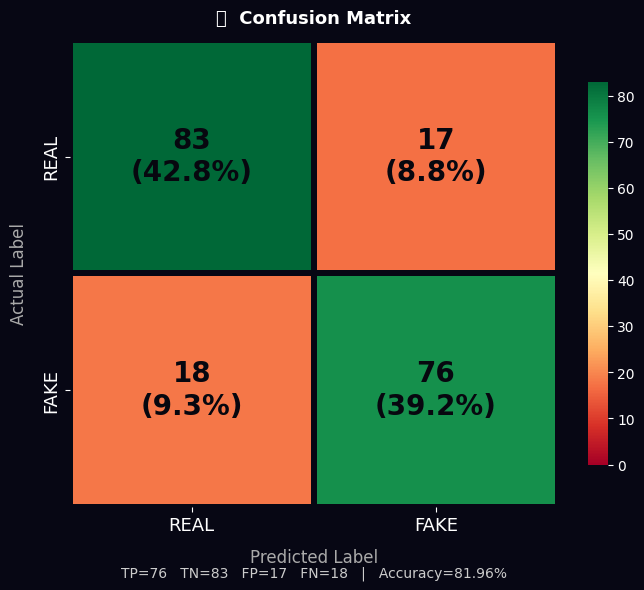

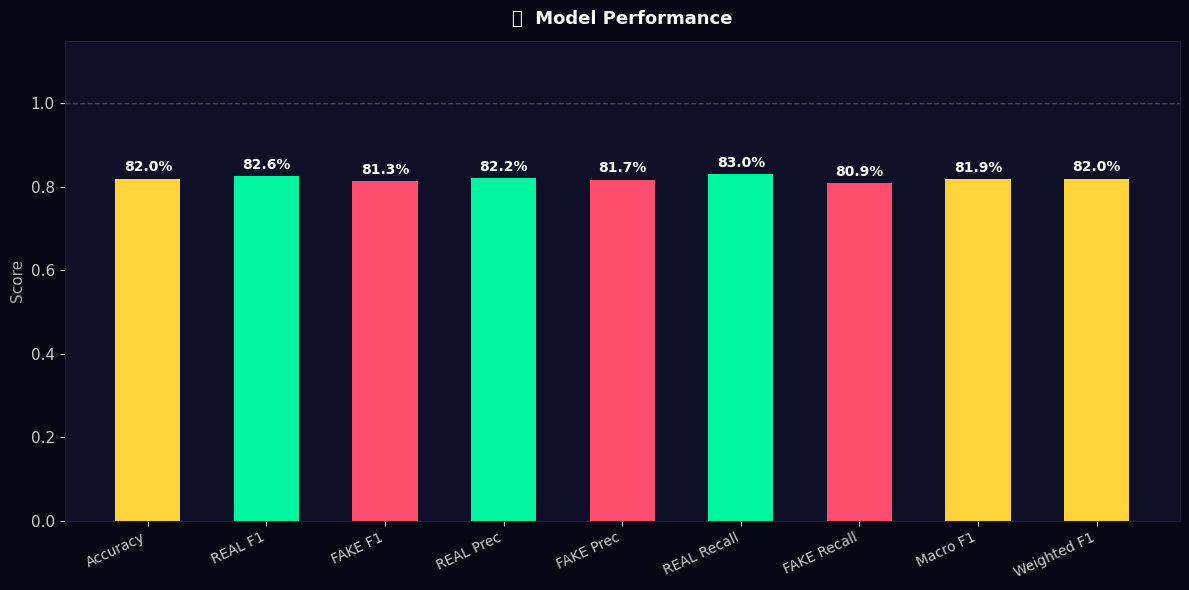

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — TRAIN + ALL OUTPUTS
#  1. Accuracy                (number)
#  2. Classification Report   (number table)
#  3. Confusion Matrix        (figure)
#  4. Accuracy bar graph      (figure)
# ══════════════════════════════════════════════════════════════

import os, re, warnings
from io import BytesIO
import numpy as np
from scipy.stats import skew, kurtosis
import cv2
from PIL import Image, ImageChops
from skimage.feature import local_binary_pattern
import pytesseract
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

DARK='#070714'; CARD='#0f0f28'
RED='#ff4d6d';  GRN='#00f5a0';  YLW='#ffd43b'

def da(ax, title='', fs=13):
    ax.set_facecolor(CARD); ax.tick_params(colors='#ccc', labelsize=11)
    for sp in ax.spines.values(): sp.set_color('#1e1e40')
    if title: ax.set_title(title, color='white', fontsize=fs, fontweight='bold', pad=12)
    ax.xaxis.label.set_color('#aaa'); ax.yaxis.label.set_color('#aaa')

FAKE_KW = ['sale','discount','free','offer','limited','deal','buy','original',
           'off','cheap','price','guarantee','authentic','genuine','best',
           'quality','new','brand','wholesale']

def image_features(path):
    pil  = Image.open(path).convert('RGB').resize((112,112))
    bgr  = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    f    = []
    for ch in cv2.split(bgr):
        f += [ch.mean(), ch.std(), float(skew(ch.ravel())), float(kurtosis(ch.ravel()))]
    sat = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)[:,:,1]
    f  += [sat.mean(), sat.std()]
    lbp  = local_binary_pattern(gray, P=16, R=2, method='uniform')
    h,_  = np.histogram(lbp.ravel(), bins=18, range=(0,18), density=True)
    f   += h.tolist()
    edges = cv2.Canny(gray,50,150)
    mag   = np.sqrt(cv2.Sobel(gray,cv2.CV_64F,1,0)**2+cv2.Sobel(gray,cv2.CV_64F,0,1)**2)
    f    += [edges.sum()/(gray.shape[0]*gray.shape[1]*255), mag.mean()]
    blur  = cv2.GaussianBlur(gray.astype(np.float32),(5,5),0)
    noise = gray.astype(np.float32)-blur
    f    += [noise.std(), np.abs(noise).mean()]
    buf   = BytesIO()
    pil.save(buf,'JPEG',quality=90); buf.seek(0)
    arr   = np.array(ImageChops.difference(pil.convert('RGB'),Image.open(buf).convert('RGB'))).astype(np.float32)
    f    += [arr.mean(), arr.std(), arr.max()]
    F     = np.abs(np.fft.fftshift(np.fft.fft2(gray.astype(np.float32))))
    hh,w  = F.shape; Y,X = np.ogrid[:hh,:w]
    dist  = np.sqrt((X-w//2)**2+(Y-hh//2)**2); tot = F.sum()+1e-9
    f    += [F[dist<min(hh,w)//6].sum()/tot,
              F[(dist>=min(hh,w)//6)&(dist<min(hh,w)//3)].sum()/tot,
              F[dist>=min(hh,w)//3].sum()/tot]
    return np.array(f, dtype=np.float32)

def nlp_features(path):
    try: text = pytesseract.image_to_string(Image.open(path).convert('RGB'),config='--psm 6').strip()
    except: text = ''
    words = re.findall(r'\b\w+\b', text.lower()); n = len(words)
    kw    = [w for w in words if w in FAKE_KW]
    vec   = np.array([
        len(text), n, len(set(words)),
        sum(1 for c in text if c.isupper()),
        sum(1 for c in text if c.isdigit()),
        sum(1 for c in text if not c.isalnum() and not c.isspace()),
        len(kw), len(set(words))/(n+1e-9),
        np.mean([len(w) for w in words]) if words else 0
    ], dtype=np.float32)
    return vec, text

def get_paths(folder, label):
    fs = sorted([os.path.join(folder,f) for f in os.listdir(folder)
                 if os.path.splitext(f)[1].lower() in IMG_EXTS])[:400]
    return fs, [label]*len(fs)

fp,fl = get_paths(FAKE_DIR,1)
rp,rl = get_paths(REAL_DIR,0)
all_paths = fp+rp; all_labels = fl+rl
print(f'Extracting features from {len(all_paths)} images...')

img_f, nlp_v, raw_texts = [], [], []
for i,p in enumerate(all_paths):
    img_f.append(image_features(p))
    v,r = nlp_features(p); nlp_v.append(v); raw_texts.append(r)
    if (i+1)%100==0 or (i+1)==len(all_paths): print(f'  {i+1}/{len(all_paths)}')

tfidf   = TfidfVectorizer(max_features=30, min_df=2, stop_words='english')
X_tfidf = tfidf.fit_transform(raw_texts).toarray()
X       = np.hstack([np.array(img_f), np.array(nlp_v), X_tfidf])
y       = np.array(all_labels)

X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)
scaler  = StandardScaler()
clf     = RandomForestClassifier(200,max_depth=10,class_weight='balanced',random_state=42,n_jobs=-1)
clf.fit(scaler.fit_transform(X_tr), y_tr)
y_pred  = clf.predict(scaler.transform(X_te))
acc     = accuracy_score(y_te, y_pred)*100
cm      = confusion_matrix(y_te, y_pred)
rpt     = classification_report(y_te, y_pred, target_names=['REAL','FAKE'], output_dict=True)
tn,fp_,fn,tp = cm.ravel()


# ══════════════════════════════
# OUTPUT 1 — Accuracy (number)
# ══════════════════════════════
print('\n' + '═'*45)
print(f'  Accuracy  :  {acc:.2f}%')
print(f'  TP={tp}  TN={tn}  FP={fp_}  FN={fn}')
print('═'*45)


# ════════════════════════════════════════
# OUTPUT 2 — Classification Report (numbers)
# ════════════════════════════════════════
print('\n' + '═'*52)
print('  CLASSIFICATION REPORT')
print('═'*52)
print(f"  {'':18} {'Precision':>10} {'Recall':>8} {'F1-Score':>10} {'Support':>8}")
print('  ' + '─'*50)
for cls in ['REAL','FAKE']:
    print(f"  {cls:18} {rpt[cls]['precision']:>10.4f} {rpt[cls]['recall']:>8.4f} {rpt[cls]['f1-score']:>10.4f} {int(rpt[cls]['support']):>8}")
print('  ' + '─'*50)
for avg in ['macro avg','weighted avg']:
    print(f"  {avg:18} {rpt[avg]['precision']:>10.4f} {rpt[avg]['recall']:>8.4f} {rpt[avg]['f1-score']:>10.4f} {int(rpt[avg]['support']):>8}")
print('═'*52)


# ════════════════════════════════════════
# OUTPUT 3 — Confusion Matrix (figure)
# ════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(7, 6))
fig1.patch.set_facecolor(DARK)
da(ax, '📊  Confusion Matrix')
annot = np.array([[f'{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)' for j in range(2)] for i in range(2)])
h = sns.heatmap(cm, annot=annot, fmt='', cmap='RdYlGn',
    xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'],
    ax=ax, linewidths=4, linecolor=DARK,
    cbar_kws={'shrink':0.82}, annot_kws={'size':20,'weight':'bold','color':'#07070f'},
    vmin=0, vmax=cm.max())
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label',    fontsize=12, labelpad=10)
ax.tick_params(labelsize=13, colors='white')
h.collections[0].colorbar.ax.tick_params(colors='white')
ax.text(0.5,-0.15, f'TP={tp}   TN={tn}   FP={fp_}   FN={fn}   |   Accuracy={acc:.2f}%',
        transform=ax.transAxes, ha='center', color='#ccc', fontsize=10)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()


# ════════════════════════════════════════
# OUTPUT 4 — Accuracy Bar Graph (figure)
# ════════════════════════════════════════
metrics = {
    'Accuracy'    : acc/100,
    'REAL F1'     : rpt['REAL']['f1-score'],
    'FAKE F1'     : rpt['FAKE']['f1-score'],
    'REAL Prec'   : rpt['REAL']['precision'],
    'FAKE Prec'   : rpt['FAKE']['precision'],
    'REAL Recall' : rpt['REAL']['recall'],
    'FAKE Recall' : rpt['FAKE']['recall'],
    'Macro F1'    : rpt['macro avg']['f1-score'],
    'Weighted F1' : rpt['weighted avg']['f1-score'],
}
labels = list(metrics.keys())
values = list(metrics.values())
colors = [GRN if 'REAL' in l else RED if 'FAKE' in l else YLW for l in labels]

fig2, ax = plt.subplots(figsize=(12, 6))
fig2.patch.set_facecolor(DARK)
da(ax, '📈  Model Performance', 13)
bars = ax.bar(labels, values, color=colors, edgecolor='none', width=0.55)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
            f'{val*100:.1f}%', ha='center', va='bottom',
            color='white', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=10)
ax.axhline(1.0, color='white', lw=1, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig('/content/accuracy_graph.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()



📤 Upload one image


Saving IMG-20250717-WA0100_aug1.jpg to IMG-20250717-WA0100_aug1.jpg


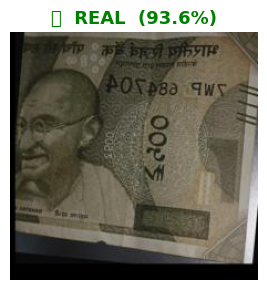


═══════════════════════════════════
  File       : IMG-20250717-WA0100_aug1.jpg
  Result     : ✅  REAL
  Confidence : 93.56%
  P(REAL)    : 93.56%
  P(FAKE)    : 6.44%
═══════════════════════════════════


In [ ]:
# CELL 4 — UPLOAD ONE IMAGE → FAKE or REAL
# Run again to predict another image
from google.colab import files as gfiles
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print('📤 Upload one image')
up    = gfiles.upload()
fname = list(up.keys())[0]
ipath = f'/content/{fname}'
open(ipath,'wb').write(up[fname])

fi     = image_features(ipath)
fv,ocr = nlp_features(ipath)
ft     = tfidf.transform([ocr]).toarray()
x      = scaler.transform(np.hstack([fi.reshape(1,-1), fv.reshape(1,-1), ft]))

pred   = clf.predict(x)[0]
proba  = clf.predict_proba(x)[0]
label  = 'FAKE' if pred==1 else 'REAL'
conf   = proba[pred]*100
p_real = proba[0]*100
p_fake = proba[1]*100
icon   = '❌' if label=='FAKE' else '✅'

# Show image with result
img = np.array(Image.open(ipath).convert('RGB'))
plt.figure(figsize=(4,3))
plt.imshow(img)
plt.title(f'{icon}  {label}  ({conf:.1f}%)', fontsize=13, fontweight='bold',
          color='red' if label=='FAKE' else 'green')
plt.axis('off')
plt.tight_layout()
plt.show()

print('\n' + '═'*35)
print(f'  File       : {fname}')
print(f'  Result     : {icon}  {label}')
print(f'  Confidence : {conf:.2f}%')
print(f'  P(REAL)    : {p_real:.2f}%')
print(f'  P(FAKE)    : {p_fake:.2f}%')
print('═'*35)